In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
from sklearn.cluster import KMeans

### Robot Sample Locations

In [2]:
# Build robot data table 
ranges = pd.read_csv('range.csv')
locations = pd.read_csv('robot_locations.csv')

robots = (
    locations.merge(ranges, on='index', how='inner')
    .rename(columns={'index': 'robot_id'})
    [['robot_id', 'longitude', 'latitude', 'range']]
    .sort_values('robot_id')
    .reset_index(drop=True)
)

#robots.to_csv('robot_table.csv', index=False)
robots.head()

,robot_id,longitude,latitude,range
0,0,-120.240815,-79.238374,127.868274
1,1,-134.537839,-83.426214,87.246488
2,2,-105.282215,-84.681705,64.393799
3,3,-105.453243,-77.964007,100.815352
4,4,-168.816260,-86.934888,36.021544


Number of robots: 1072
Longitude range: -179.589 to 179.986
Latitude range: -89.992 to -63.988
Robot range: 10.743 to 173.899


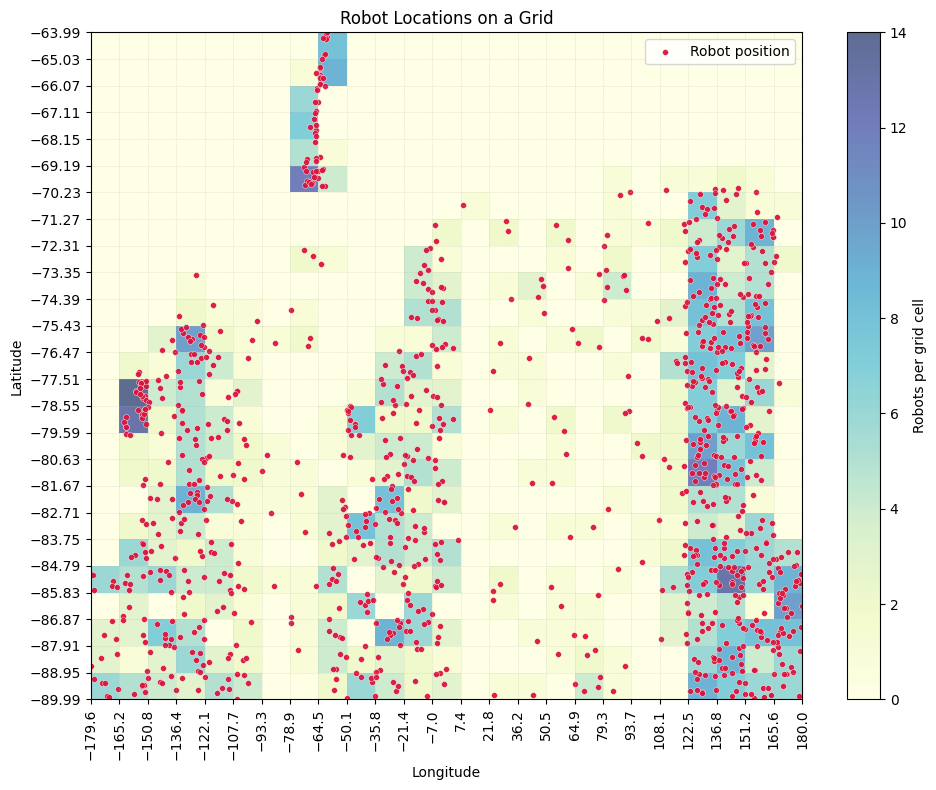

In [3]:
print(f'Number of robots: {len(robots)}')
print(f'Longitude range: {robots.longitude.min():.3f} to {robots.longitude.max():.3f}')
print(f'Latitude range: {robots.latitude.min():.3f} to {robots.latitude.max():.3f}')
print(f'Robot range: {robots["range"].min():.3f} to {robots["range"].max():.3f}')

grid_size = 25
lon_edges = np.linspace(robots['longitude'].min(), robots['longitude'].max(), grid_size + 1)
lat_edges = np.linspace(robots['latitude'].min(), robots['latitude'].max(), grid_size + 1)

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.hist2d(
    robots['longitude'],
    robots['latitude'],
    bins=[lon_edges, lat_edges],
    cmap='YlGnBu',
    alpha=0.65
)
ax.scatter(
    robots['longitude'],
    robots['latitude'],
    s=18,
    c='crimson',
    edgecolors='white',
    linewidths=0.3,
    marker='o',
    alpha=0.95,
    label='Robot position'
)
plt.colorbar(heatmap[3], ax=ax, label='Robots per grid cell')
ax.set_title('Robot Locations on a Grid')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xticks(lon_edges)
ax.set_yticks(lat_edges)
ax.tick_params(axis='x', labelrotation=90)
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [4]:
# Random sample of robots

robots_subset = robots.sample(n=300, random_state=1).reset_index(drop=True).copy()

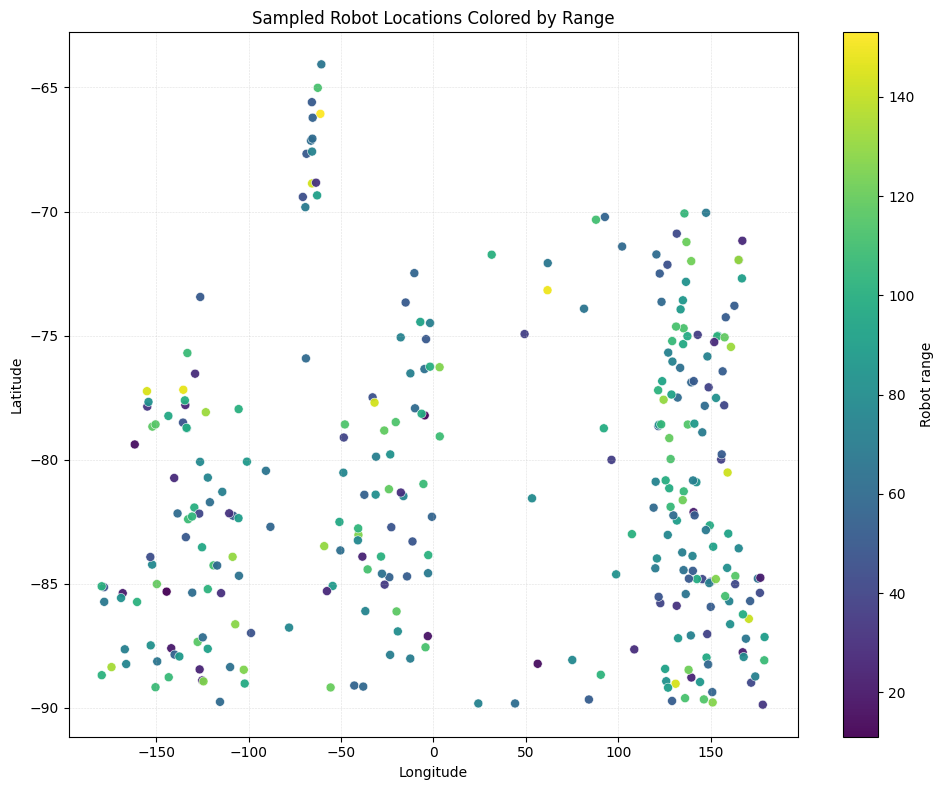

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    robots_subset['longitude'],
    robots_subset['latitude'],
    c=robots_subset['range'],
    cmap='viridis',
    s=42,
    edgecolors='white',
    linewidths=0.4,
    alpha=0.95
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Robot range')
ax.set_title('Sampled Robot Locations Colored by Range')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)
plt.tight_layout()
plt.show()


### Model

In [6]:
# Model parameters from the assignment.
planning_days = 365 # run model for a year to account for annual costs
m = 8
q = 2
c_b = 5000
c_h = 1000
c_m = 500
c_c = 0.42
lambda_ = 0.012
r_min = 10
r_max = 175


#### Location

In [31]:
coords = robots_subset[["longitude", "latitude"]].to_numpy()

def pairwise_sqdist(a, b):
    return ((a[:, None, :] - b[None, :, :]) ** 2).sum(axis=2)

def farthest_first_init(points, k, start_index=0):
    chosen = [start_index]

    while len(chosen) < k:
        chosen_points = points[chosen]
        sq_dists = pairwise_sqdist(points, chosen_points)
        min_sq_dist = sq_dists.min(axis=1)
        next_idx = int(np.argmax(min_sq_dist))
        chosen.append(next_idx)

    return chosen


In [32]:
k_values = [75,80,85,90,95,100]
stations_by_k = {}

for k in k_values:
    init_indices = farthest_first_init(coords, k, start_index=0)

    stations = pd.DataFrame(
        coords[init_indices],
        columns=["longitude", "latitude"]
    )
    stations["station_id"] = range(k)
    stations["k"] = k
    stations = stations[["k", "station_id", "longitude", "latitude"]]

    stations_by_k[k] = stations

    print(f"k = {k}: created {len(stations)} initial stations")


k = 75: created 75 initial stations
k = 80: created 80 initial stations
k = 85: created 85 initial stations
k = 90: created 90 initial stations
k = 95: created 95 initial stations
k = 100: created 100 initial stations


In [30]:
coords = robots_subset[["longitude", "latitude"]].to_numpy() # coordinates for clustering
weights = 1.0 / np.maximum(robots_subset["range"].to_numpy(), 1e-6) # weight by inverse of range to prioritize closer robots

# k = number of stations to try for run
k_values = [80]
# k_values = range(2, 7)

stations_by_k = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(coords, sample_weight=weights)

    stations = pd.DataFrame(
        km.cluster_centers_,
        columns=["longitude", "latitude"]
    )
    stations["station_id"] = range(k)
    stations["k"] = k
    stations = stations[["k", "station_id", "longitude", "latitude"]]

    stations_by_k[k] = stations

    print(f"k = {k}: created {len(stations)} initial stations")

display(stations_by_k[k_values[0]])


k = 80: created 80 initial stations


,k,station_id,longitude,latitude
0,80,0,-125.204824,-88.077483
1,80,1,130.410961,-76.239416
2,80,2,-10.142449,-75.341671
3,80,3,-64.315513,-66.984461
4,80,4,165.749330,-72.107903
...,...,...,...,...
75,80,75,96.382762,-80.009725
76,80,76,172.161268,-87.673306
77,80,77,147.578346,-70.050752
78,80,78,-40.471837,-89.126780


In [33]:
def plot_initial_stations(robots_df, stations_by_k, k_values, mode="one", selected_k=None):
    """
    mode = "one"  -> plot only selected_k
    mode = "all"  -> plot every k in k_values
    """

    if mode == "one":
        if selected_k is None:
            selected_k = k_values[0]

        stations = stations_by_k[selected_k]

        fig, ax = plt.subplots(figsize=(10, 8))

        ax.scatter(
            robots_df["longitude"],
            robots_df["latitude"],
            c="red",
            s=40,
            label="Robots"
        )

        ax.scatter(
            stations["longitude"],
            stations["latitude"],
            c="blue",
            s=140,
            marker="X",
            label="Initial stations"
        )

        for _, row in stations.iterrows():
            ax.text(
                row["longitude"],
                row["latitude"],
                f"S{int(row['station_id'])}",
                fontsize=9,
                ha="left",
                va="bottom",
                color="black"
            )

        ax.set_title(f"Initial Station Locations and Robots (k = {selected_k})")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    elif mode == "all":
        for k in k_values:
            stations = stations_by_k[k]

            fig, ax = plt.subplots(figsize=(10, 8))

            ax.scatter(
                robots_df["longitude"],
                robots_df["latitude"],
                c="red",
                s=40,
                label="Robots"
            )

            ax.scatter(
                stations["longitude"],
                stations["latitude"],
                c="blue",
                s=140,
                marker="X",
                label="Initial stations"
            )

            for _, row in stations.iterrows():
                ax.text(
                    row["longitude"],
                    row["latitude"],
                    f"S{int(row['station_id'])}",
                    fontsize=9,
                    ha="left",
                    va="bottom",
                    color="black"
                )

            ax.set_title(f"Initial Station Locations and Robots (k = {k})")
            ax.set_xlabel("Longitude")
            ax.set_ylabel("Latitude")
            ax.grid(True, alpha=0.3)
            ax.legend()
            plt.xticks(rotation=90)
            plt.tight_layout()
            plt.show()

    else:
        raise ValueError("mode must be 'one' or 'all'")


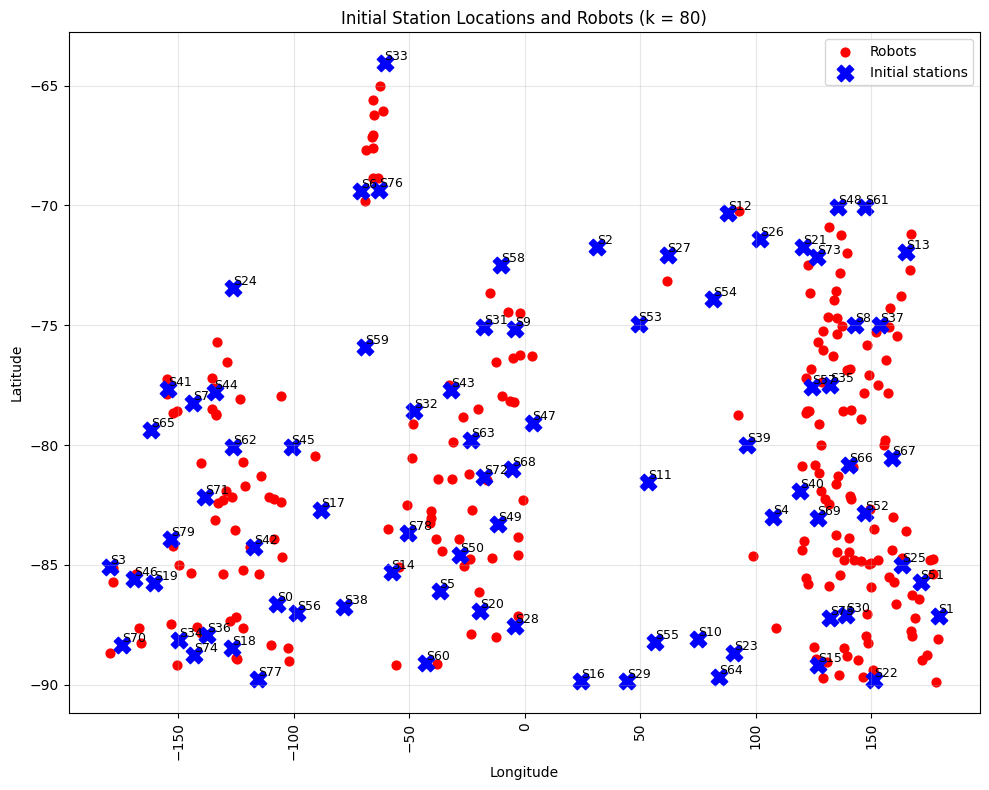

In [34]:
plot_initial_stations(
    robots_df=robots_subset,
    stations_by_k=stations_by_k,
    k_values=k_values,
    mode="one",
    selected_k=80
)


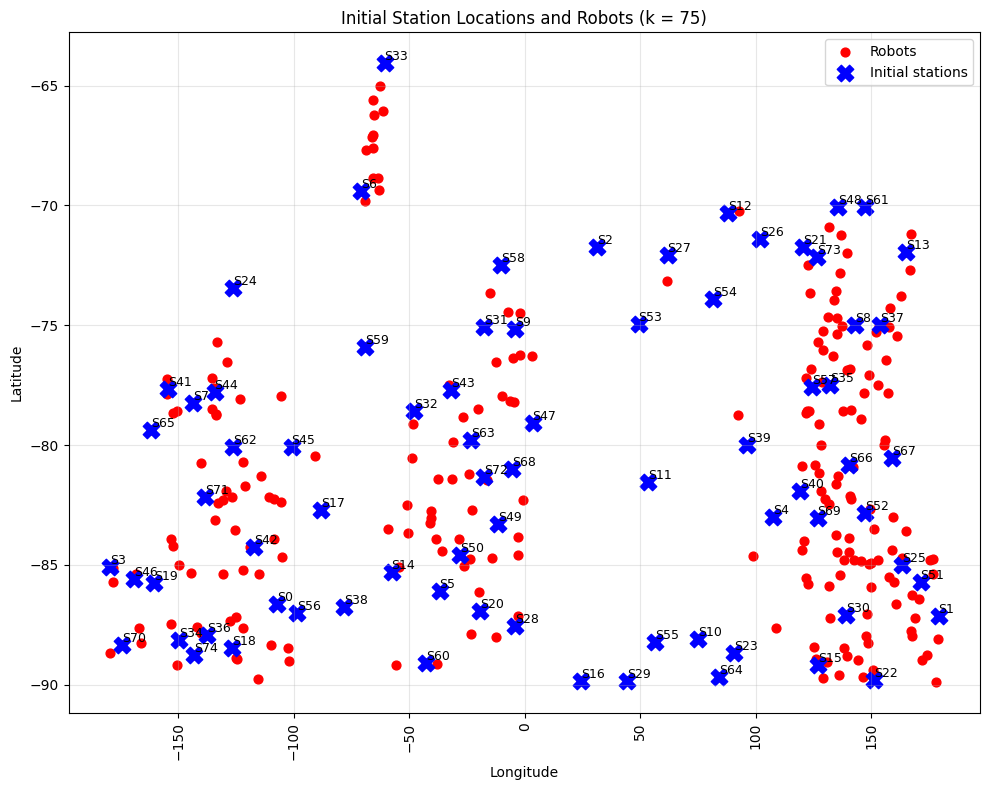

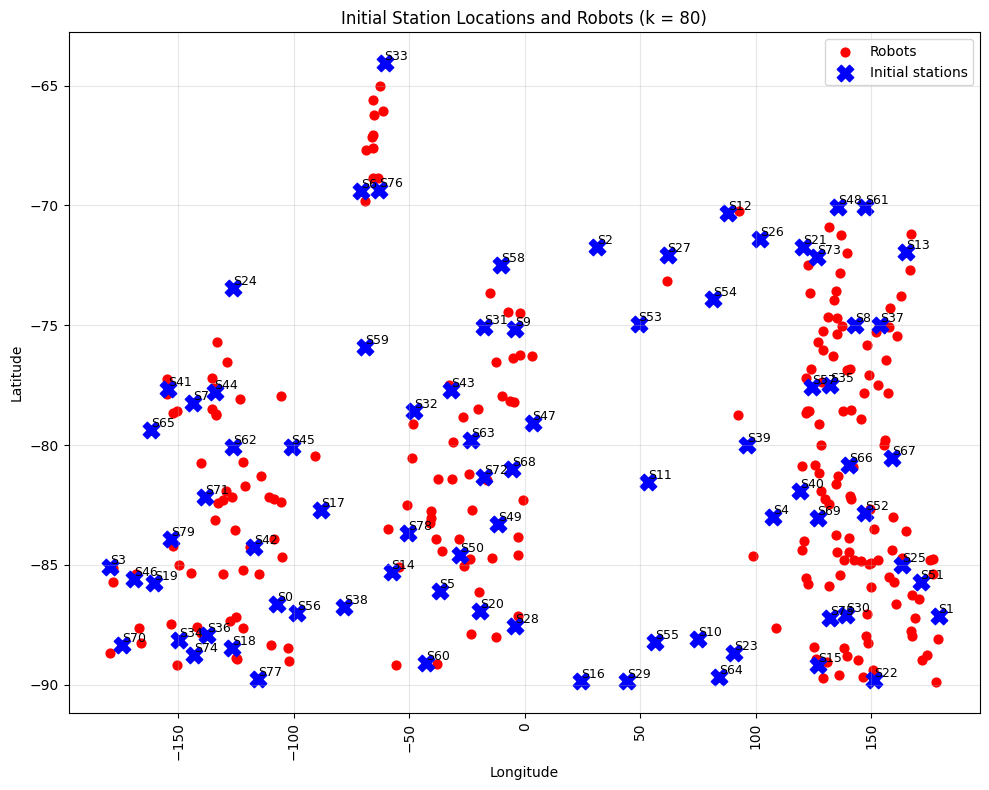

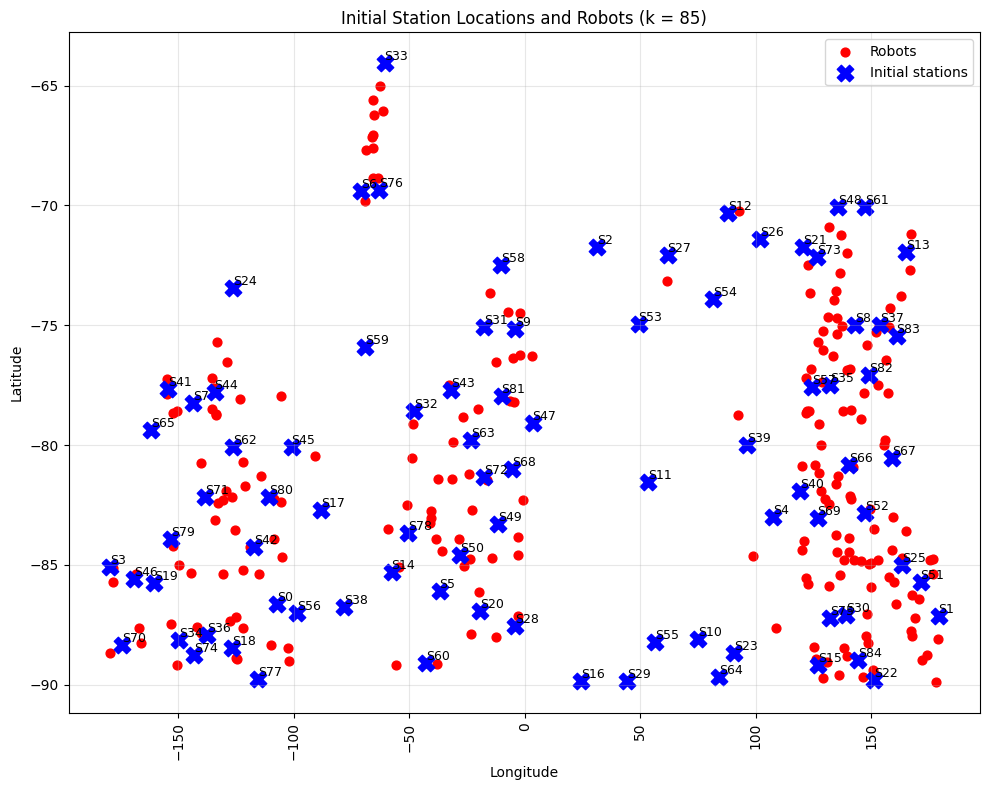

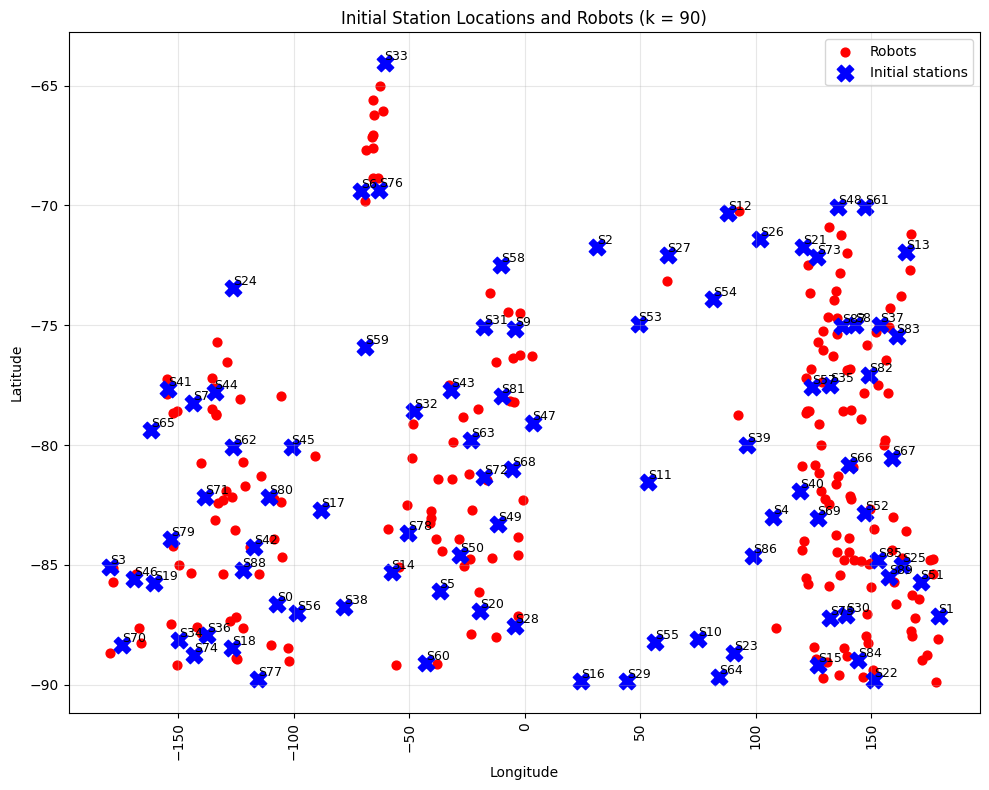

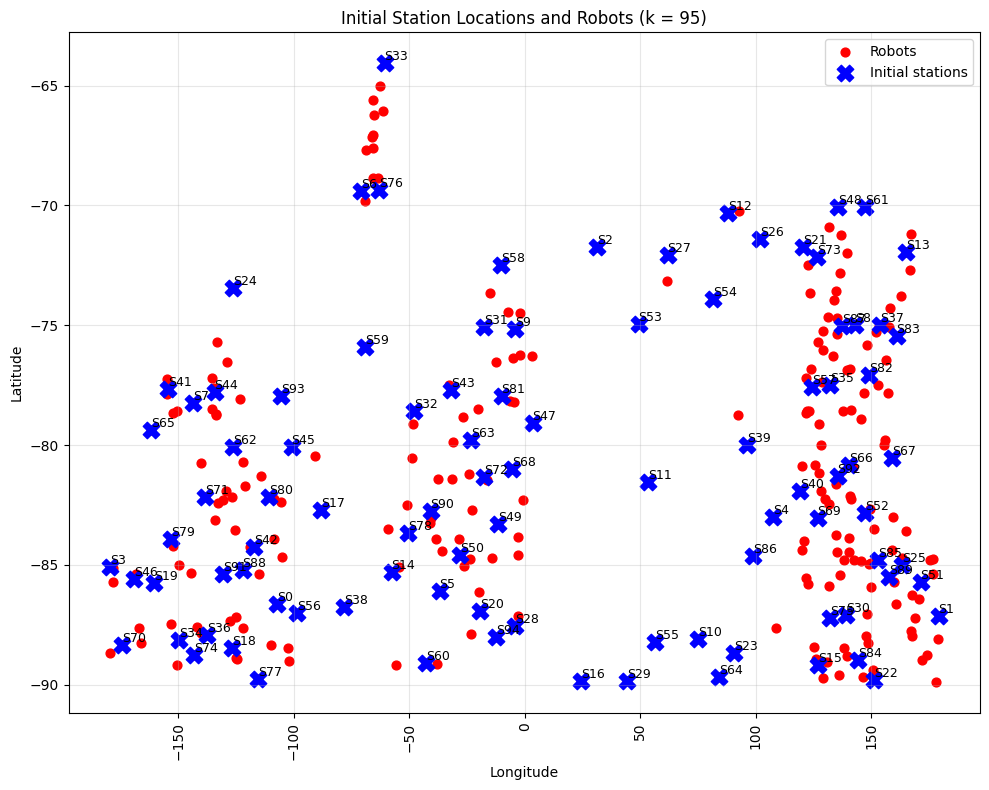

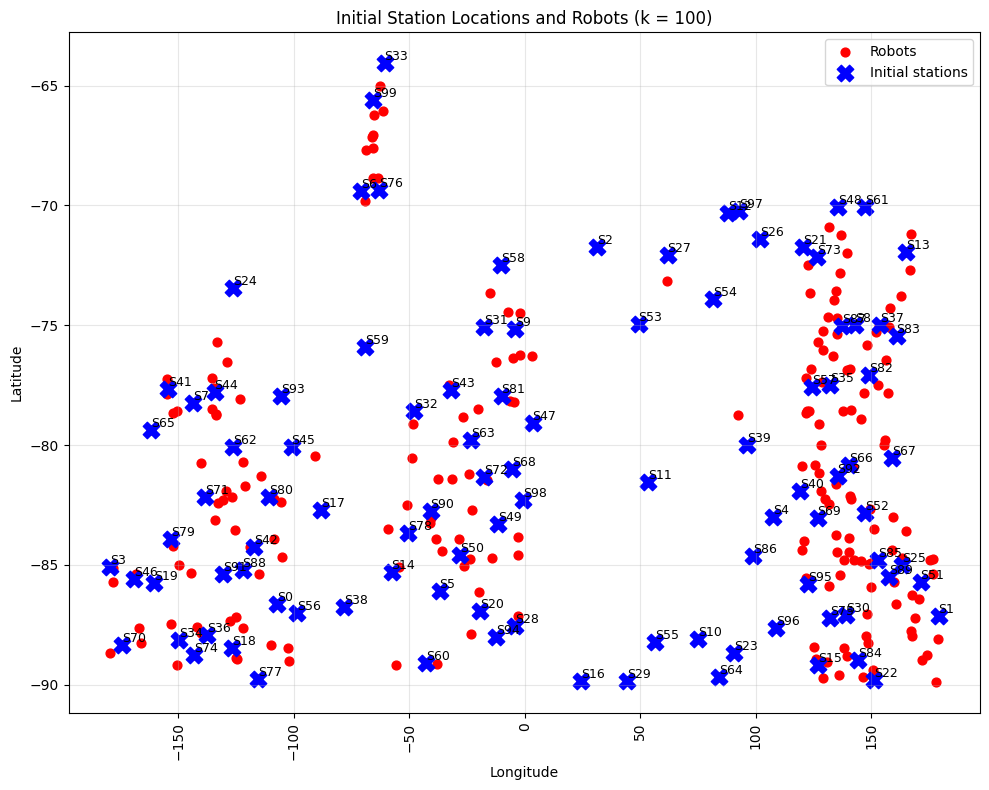

In [35]:
plot_initial_stations(
    robots_df=robots_subset,
    stations_by_k=stations_by_k,
    k_values=k_values,
    mode="all"
)


#### Allocation

Function allocates each robot to one candidate station, subject to the capacity constraints of the stations. 

What happens inside:
1) Compute maximum robot capacity per station:
m * q

because each station can have at most m chargers and each charger can serve q robots.

2) For every robot-station pair:
 - compute distance
 - check whether the robot can reach the station
 - compute charging cost
 - compute transport penalty if needed
 - compute total assignment cost

3) Store all robot-station assignment possibilities in one table.

4) Sort those possibilities by cheapest assignment cost.

5) Greedily assign robots:
 - if robot already assigned, skip
 - if station is full, skip
 - otherwise assign robot to that station

Outputs:
 - assignments_df: which robot is assigned to which station
 - station_load: number of assigned robots at each station

In [36]:
def allocation_step(robots_subset, stations, planning_days, m, q, c_c, c_h, r_max):
    
    station_capacity = m * q # max number of robots a station can serve
    assignment_options = [] # list to store all possible robot-station assignment options

    for _, robot in robots_subset.iterrows(): # loop over every robot
        i = int(robot["robot_id"]) # robot ID
        r_i = float(robot["range"]) # robot's range
        robot_lon = float(robot["longitude"]) # robot's longitude
        robot_lat = float(robot["latitude"]) # robot's latitude

        for _, station in stations.iterrows(): # loop over every station 
            j = int(station["station_id"]) # station ID
            station_lon = float(station["longitude"]) # station longitude
            station_lat = float(station["latitude"]) # station latitude

            # robot-station euclidean distance
            d_ij = np.sqrt(
                (robot_lon - station_lon) ** 2 +
                (robot_lat - station_lat) ** 2
            )

            # binary variable indicating if robot i is unreachable from station j
            unreachable = int(d_ij > r_i)

            # Charging cost:
            # reachable   -> c_c * (r_max - r_i + d_ij)
            # unreachable -> c_c * (r_max - r_i)
            charging_cost = planning_days * c_c * (
                (r_max - r_i + d_ij) * (1 - unreachable)
                + (r_max - r_i) * unreachable
            )

            # Transport penalty if unreachable
            transport_cost = planning_days * c_h * unreachable

            total_cost = charging_cost + transport_cost

            assignment_options.append({
                "robot_id": i,
                "station_id": j,
                "distance": d_ij,
                "unreachable": unreachable,
                "assign_cost": total_cost
            })



    # Sort all assignment options by cost (lowest first)
    assignment_options_df = pd.DataFrame(assignment_options).sort_values(
        by="assign_cost"
    ).reset_index(drop=True)

    assigned_robots = set() #set of asigned robots
    station_load = {j: 0 for j in stations["station_id"]} # number of robots assigned to station j 
    assignments = [] # list to store assignments


    # Greedy assignment over all robot-station pairs, cheapest first
    for _, row in assignment_options_df.iterrows(): # loop over all assignment options sorted by cost
        i = int(row["robot_id"]) # robot ID
        j = int(row["station_id"]) # station ID

        # skip if robot is already assigned
        if i in assigned_robots: 
            continue

        # skip if station is at capacity
        if station_load[j] >= station_capacity:
            continue

        # accept assignment 
        assignments.append({
            "robot_id": i,
            "station_id": j,
            "distance": float(row["distance"]),
            "unreachable": int(row["unreachable"]),
            "assign_cost": float(row["assign_cost"])
        })

        assigned_robots.add(i) # robot i has now been assigned 
        station_load[j] += 1 # station j now has one more assigned robot 

    assignments_df = pd.DataFrame(assignments)

    #if len(assignments_df) != len(robots_subset):
    #    raise RuntimeError("Not all robots were assigned in the allocation step.")

    return assignments_df, station_load


#### Location Update

At this stage:
 - robot assignments are fixed
 - station locations are changed

The idea is:
 - if a station is currently serving a certain group of robots then it should move toward those robots with extra pull from robots with smaller ranges (to avoid rescue penalties)
 
So this step tries to improve the station layout while holding assignments fixed.

In [37]:
def location_update_step(robots_subset, stations, assignments_df):
    updated_stations = stations.copy()

    for j in updated_stations["station_id"]: # loop over every station j

        # extract robot ids of assigned robots for station j
        assigned_robot_ids = assignments_df.loc[
            assignments_df["station_id"] == j, "robot_id"
        ].tolist()

        # skip if station has no assigned robots
        if len(assigned_robot_ids) == 0:
            continue

        # create dataframe of only robots assigned to station j
        assigned_robots_df = robots_subset[
            robots_subset["robot_id"].isin(assigned_robot_ids)
        ].copy()

        # weights inversely proportional to robot range
        weights = 1.0 / np.maximum(assigned_robots_df["range"].to_numpy(), 1e-6)

        # define new location of station j (weighted average of assigned robot locations)
        new_longitude = np.average(assigned_robots_df["longitude"], weights=weights)
        new_latitude = np.average(assigned_robots_df["latitude"], weights=weights)

        updated_stations.loc[
            updated_stations["station_id"] == j, "longitude"
        ] = new_longitude

        updated_stations.loc[
            updated_stations["station_id"] == j, "latitude"
        ] = new_latitude

    return updated_stations


#### Evaluation

Function computes charger counts and total annual cost for the current solution.

What happens inside
1) Compute station loads:
Count how many robots are assigned to each station.

2) Compute chargers needed:
For each station:
z_j = âŒˆrobots assigned / q âŒ‰.
This is the minimum number of chargers required.

3) Check feasibility:
Verify: z_j â‰¤ m
for every station.
If any station needs more than m chargers, the current solution is infeasible.

4) Recompute assignment costs:
Because the station locations have just changed, distances must be recomputed.
For every assigned robot-station pair:
 - recompute d_ij
 - determine if unreachable
 - compute charging cost
 - compute transport cost
 - compute total assignment cost
 - E. Compute total annual cost

Total cost = station build cost + charger maintenance cost + charging cost + transport cost

In [38]:
def evaluation_step(robots_subset, updated_stations, assignments_df, planning_days, q, m, c_b, c_m, c_c, c_h, r_max):

    # count number of robots assigned to each station
    station_loads_df = (
        assignments_df.groupby("station_id")
        .size()
        .reset_index(name="robots_assigned")
    )

    solution_stations = updated_stations.merge(
        station_loads_df,
        on="station_id",
        how="left"
    )

    # fill nan values
    solution_stations["robots_assigned"] = solution_stations["robots_assigned"].fillna(0).astype(int)

    # chargers needed at each station = ceil(robots_assigned / q)
    solution_stations["chargers"] = np.ceil(solution_stations["robots_assigned"] / q).astype(int)
    solution_stations["feasible_station"] = solution_stations["chargers"] <= m # check feasability

    solution_feasible = solution_stations["feasible_station"].all()

    assignment_cost_records = [] # list to store updated assignment costs 

    # calculate new assignment costs based on upated station locations
    for _, row in assignments_df.iterrows():
        i = int(row["robot_id"])
        j = int(row["station_id"])

        robot = robots_subset[robots_subset["robot_id"] == i].iloc[0]
        station_row = solution_stations[solution_stations["station_id"] == j].iloc[0]

        r_i = float(robot["range"])

        d_ij = np.sqrt(
            (robot["longitude"] - station_row["longitude"]) ** 2 +
            (robot["latitude"] - station_row["latitude"]) ** 2
        )

        unreachable = int(d_ij > r_i)

        charging_cost = planning_days * c_c * (
            (r_max - r_i + d_ij) * (1 - unreachable)
            + (r_max - r_i) * unreachable
        )

        transport_cost = planning_days * c_h * unreachable
        total_cost = charging_cost + transport_cost

        assignment_cost_records.append({
            "robot_id": i,
            "station_id": j,
            "distance": d_ij,
            "unreachable": unreachable,
            "charging_cost": charging_cost,
            "transport_cost": transport_cost,
            "assign_cost": total_cost
        })

    solution_assignments = pd.DataFrame(assignment_cost_records)

    num_open_stations = (solution_stations["robots_assigned"] > 0).sum() # number of stations used
    fixed_cost = num_open_stations * c_b + solution_stations["chargers"].sum() * c_m # fixed costs 
    charging_cost_total = solution_assignments["charging_cost"].sum() # total charging costs
    transport_cost_total = solution_assignments["transport_cost"].sum() # total transport costs 
    total_solution_cost = fixed_cost + charging_cost_total + transport_cost_total # total cost of solution 

    return solution_stations, solution_assignments, total_solution_cost, solution_feasible


#### RUN HEURISTIC

This function runs a single-pass continuous construction heuristic using the previous three steps: Allocation, Location Update, and Evaluation.


In [ ]:
def run_construction_heuristic(
    robots_subset,
    initial_stations,
    planning_days,
    m,
    q,
    c_b,
    c_m,
    c_c,
    c_h,
    r_max,
    verbose=True
):
    stations_initial = initial_stations.copy()

    # Step 1: Initial assignment using initial station locations
    assignments_initial_df, station_load_initial = allocation_step(
        robots_subset, stations_initial, planning_days, m, q, c_c, c_h, r_max
    )

    solution_stations_initial, solution_assignments_initial, initial_total_cost, initial_feasible = evaluation_step(
        robots_subset, stations_initial, assignments_initial_df,
        planning_days, q, m, c_b, c_m, c_c, c_h, r_max
    )

    # Step 2: Move station locations once
    stations_updated = location_update_step(
        robots_subset, stations_initial, assignments_initial_df
    )

    # Step 3: Re-evaluate after movement
    solution_stations_final, solution_assignments_final, final_total_cost, final_feasible = evaluation_step(
        robots_subset, stations_updated, assignments_initial_df,
        planning_days, q, m, c_b, c_m, c_c, c_h, r_max
    )

    if verbose:
        print(f"Initial assignment cost: {initial_total_cost:,.2f}")
        print(f"Post-movement cost: {final_total_cost:,.2f}")
        print(f"Improvement: {initial_total_cost - final_total_cost:,.2f}")
        print(f"Initial feasible: {initial_feasible}, Final feasible: {final_feasible}")

    return {
        "initial_stations": solution_stations_initial,
        "initial_assignments": solution_assignments_initial,
        "initial_total_cost": initial_total_cost,
        "initial_feasible": initial_feasible,
        "final_stations": solution_stations_final,
        "final_assignments": solution_assignments_final,
        "final_total_cost": final_total_cost,
        "final_feasible": final_feasible,
        "improvement": initial_total_cost - final_total_cost
    }


#### Run the Construction Heuristic


- Run first box for a single k value
- Run the second box for all of the k values


In [40]:
k = 80
result_k4 = run_construction_heuristic(
    robots_subset=robots_subset,
    initial_stations=stations_by_k[k],
    planning_days=planning_days,
    m=m,
    q=q,
    c_b=c_b,
    c_m=c_m,
    c_c=c_c,
    c_h=c_h,
    r_max=r_max,
    verbose=True
)

print("Final cost:", result_k4["final_total_cost"])
display(result_k4["final_stations"])
display(result_k4["final_assignments"].head(20))


Single-pass construction: cost = 5,090,427.38, open stations = 80, chargers = 177, feasible = True
Final cost: 5090427.384480071


,k,station_id,longitude,latitude,robots_assigned,chargers,feasible_station
0,80,0,-108.458404,-83.901250,7,4,True
1,80,1,177.628005,-86.652397,5,3,True
2,80,2,31.520712,-71.740210,1,1,True
3,80,3,-178.737350,-85.920099,4,2,True
4,80,4,108.435256,-86.619366,2,1,True
...,...,...,...,...,...,...,...
75,80,75,132.828734,-85.301690,6,3,True
76,80,76,-64.996216,-67.493213,8,4,True
77,80,77,-115.538721,-89.763822,1,1,True
78,80,78,-50.578081,-83.209355,2,1,True


,robot_id,station_id,distance,unreachable,charging_cost,transport_cost,assign_cost
0,1019,33,1.302747,0,3568.963449,0,3568.963449
1,516,27,0.758487,0,4049.486242,0,4049.486242
2,27,44,1.556605,0,4457.363310,0,4457.363310
3,205,41,1.407904,0,4882.431120,0,4882.431120
4,403,43,1.312960,0,5046.249702,0,5046.249702
5,921,67,1.676414,0,5263.874581,0,5263.874581
6,777,75,4.115613,0,5422.654795,0,5422.654795
7,984,76,1.551053,0,5072.490076,0,5072.490076
8,719,51,1.006257,0,5369.381195,0,5369.381195
9,50,70,0.000000,0,6282.193023,0,6282.193023


In [41]:
results_by_k = {}

for k in k_values:
    print(f"`nRunning construction heuristic for k = {k}")
    
    results_by_k[k] = run_construction_heuristic(
        robots_subset=robots_subset,
        initial_stations=stations_by_k[k],
        planning_days=planning_days,
        m=m,
        q=q,
        c_b=c_b,
        c_m=c_m,
        c_c=c_c,
        c_h=c_h,
        r_max=r_max,
        verbose=False
    )

    print(f"k = {k}, final cost = {results_by_k[k]['final_total_cost']:,.2f}, feasible = {results_by_k[k]['feasible']}")


`nRunning construction heuristic for k = 75
k = 75, final cost = 5,071,394.37, feasible = True
`nRunning construction heuristic for k = 80
k = 80, final cost = 5,090,427.38, feasible = True
`nRunning construction heuristic for k = 85
k = 85, final cost = 5,109,220.18, feasible = True
`nRunning construction heuristic for k = 90
k = 90, final cost = 5,128,166.54, feasible = True
`nRunning construction heuristic for k = 95
k = 95, final cost = 5,148,089.67, feasible = True
`nRunning construction heuristic for k = 100
k = 100, final cost = 5,169,233.27, feasible = True


### Results

In [42]:
summary_by_k = pd.DataFrame([
    {
        "k": k,
        "final_cost": results_by_k[k]["final_total_cost"],
        "feasible": results_by_k[k]["feasible"],
        "num_open_stations": int((results_by_k[k]["final_stations"]["robots_assigned"] > 0).sum()),
        "total_chargers": int(results_by_k[k]["final_stations"]["chargers"].sum()),
        "transport_robots": int(results_by_k[k]["final_assignments"]["unreachable"].sum())
    }
    for k in k_values
])

display(summary_by_k.sort_values("final_cost"))


,k,final_cost,feasible,num_open_stations,total_chargers,transport_robots
0,75,5.071394e+06,True,75,175,0
1,80,5.090427e+06,True,80,177,0
2,85,5.109220e+06,True,85,177,0
3,90,5.128167e+06,True,90,175,0
4,95,5.148090e+06,True,95,178,0
5,100,5.169233e+06,True,100,181,0


In [19]:
# Extract the best solution across all tested k values

best_k = summary_by_k.loc[summary_by_k["final_cost"].idxmin(), "k"]
best_result = results_by_k[best_k]

best_stations_df = best_result["final_stations"].copy()
best_assignments_df = best_result["final_assignments"].copy()
best_total_cost = best_result["final_total_cost"]
best_cost_history = best_result["cost_history"]

print("Best k:", best_k)
print("Best total cost:", best_total_cost)
print("Feasible:", best_result["feasible"])

display(best_stations_df)
display(best_assignments_df.head(20))


Best k: 80
Best total cost: 5079505.020350401
Feasible: True


,k,station_id,longitude,latitude,robots_assigned,chargers,feasible_station
0,80,0,-125.204824,-88.077483,7,4,True
1,80,1,130.410961,-76.239416,7,4,True
2,80,2,-10.142449,-75.341671,4,2,True
3,80,3,-64.315513,-66.984461,11,6,True
4,80,4,165.749330,-72.107903,5,3,True
...,...,...,...,...,...,...,...
75,80,75,96.382762,-80.009725,1,1,True
76,80,76,172.161268,-87.673306,4,2,True
77,80,77,147.578346,-70.050752,1,1,True
78,80,78,-40.471837,-89.126780,2,1,True


,robot_id,station_id,distance,unreachable,charging_cost,transport_cost,assign_cost
0,1019,3,3.252650,0,3867.883599,0,3867.883599
1,516,25,0.758487,0,4049.486242,0,4049.486242
2,27,16,2.134998,0,4546.030871,0,4546.030871
3,205,22,1.407904,0,4882.431120,0,4882.431120
4,403,17,1.312960,0,5046.249702,0,5046.249702
5,984,3,2.346070,0,5194.366214,0,5194.366214
6,777,35,3.236165,0,5287.835356,0,5287.835356
7,921,48,2.680601,0,5417.816464,0,5417.816464
8,719,76,1.903306,0,5506.898789,0,5506.898789
9,677,4,0.596705,0,6900.024537,0,6900.024537


In [43]:
best_k = summary_by_k.loc[summary_by_k["final_cost"].idxmin(), "k"]
best_result = results_by_k[best_k]

best_stations_df = best_result["final_stations"].copy()
best_assignments_df = best_result["final_assignments"].copy()
best_total_cost = best_result["final_total_cost"]
best_cost_history = best_result["cost_history"]


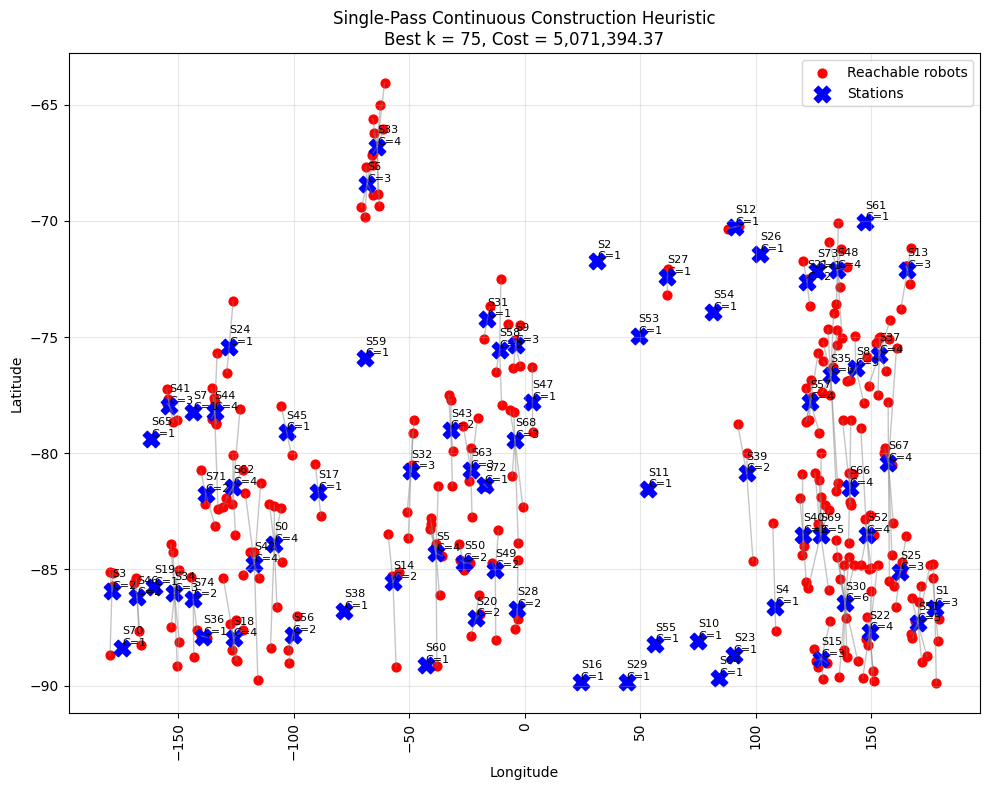

In [44]:
fig, ax = plt.subplots(figsize=(10, 8))

transport_robot_ids = set(
    best_assignments_df.loc[best_assignments_df["unreachable"] == 1, "robot_id"]
)

reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

ax.scatter(
    reachable_robots["longitude"],
    reachable_robots["latitude"],
    c="red",
    s=40,
    label="Reachable robots"
)

if not transport_robots.empty:
    ax.scatter(
        transport_robots["longitude"],
        transport_robots["latitude"],
        c="darkorange",
        s=55,
        label="Transport-needed robots"
    )

ax.scatter(
    best_stations_df["longitude"],
    best_stations_df["latitude"],
    c="blue",
    s=140,
    marker="X",
    label="Stations"
)

for _, row in best_stations_df.iterrows():
    ax.text(
        row["longitude"],
        row["latitude"],
        f"S{int(row['station_id'])}\nC={int(row['chargers'])}",
        fontsize=8,
        ha="left",
        va="bottom",
        color="black"
    )

for _, row in best_assignments_df.iterrows():
    robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
    station = best_stations_df[best_stations_df["station_id"] == row["station_id"]].iloc[0]

    line_color = "darkorange" if row["unreachable"] == 1 else "gray"

    ax.plot(
        [robot["longitude"], station["longitude"]],
        [robot["latitude"], station["latitude"]],
        color=line_color,
        alpha=0.45,
        linewidth=1
    )

ax.set_title(f"Single-Pass Continuous Construction Heuristic\nBest k = {best_k}, Cost = {best_total_cost:,.2f}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


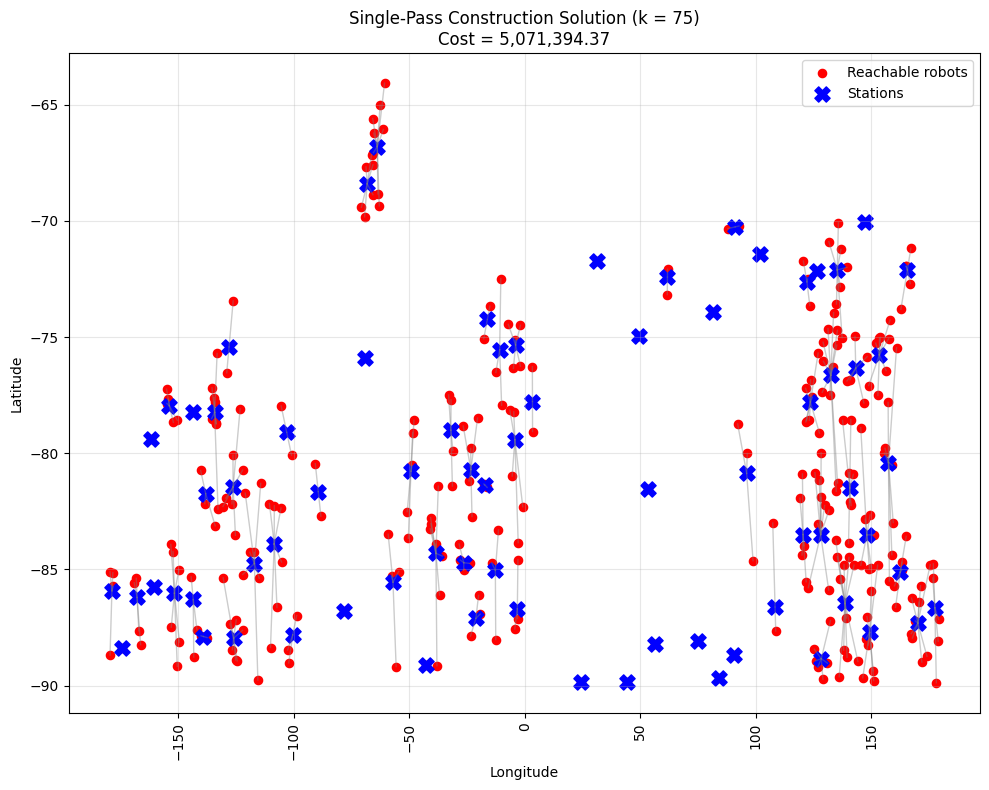

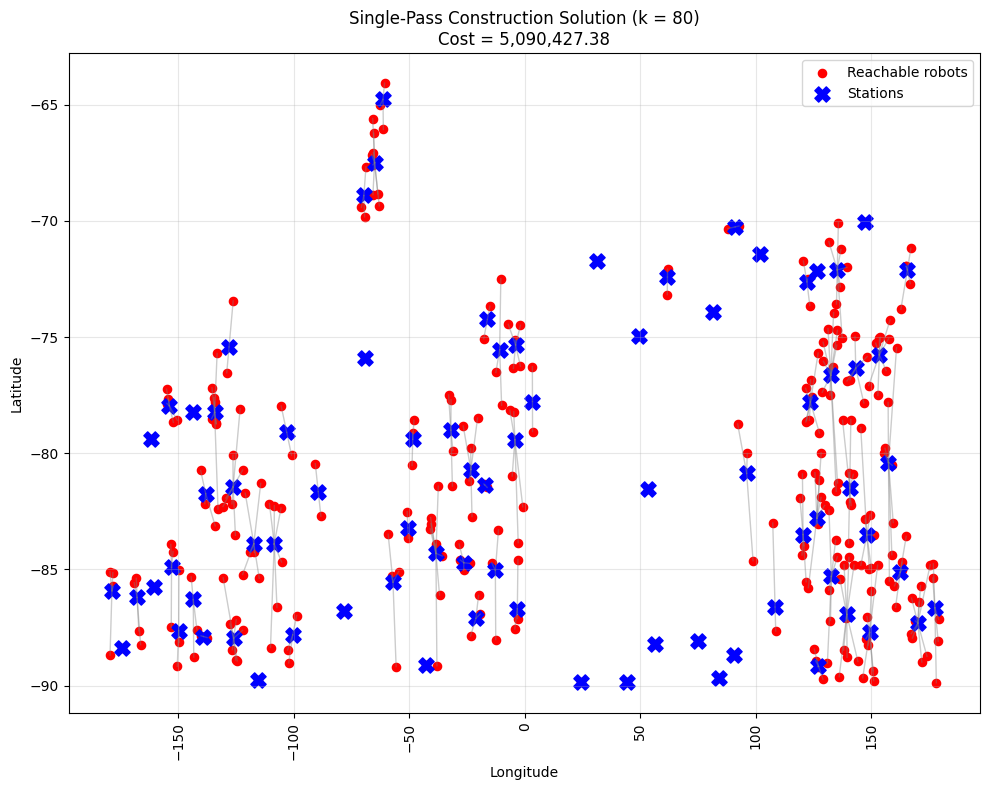

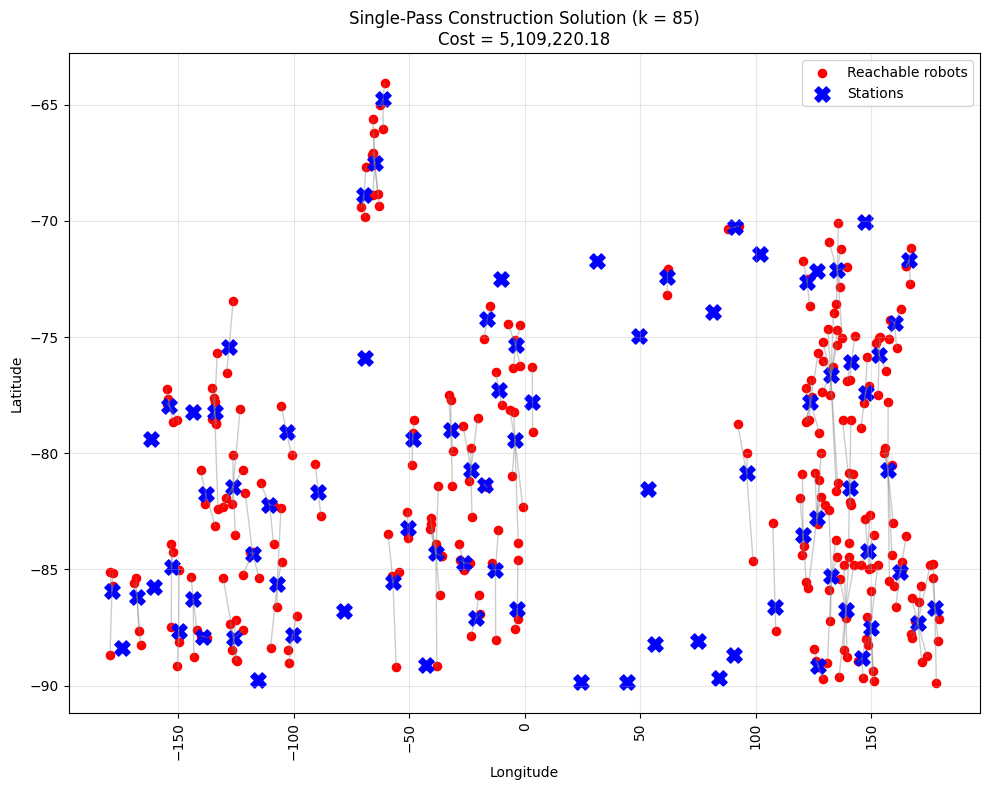

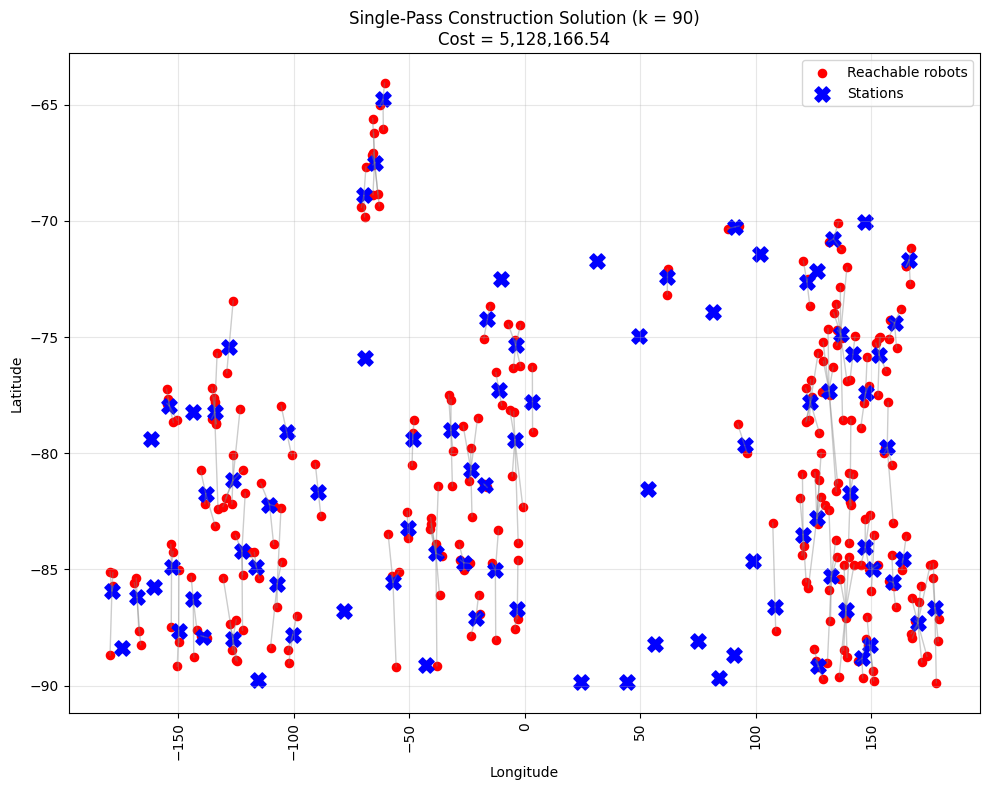

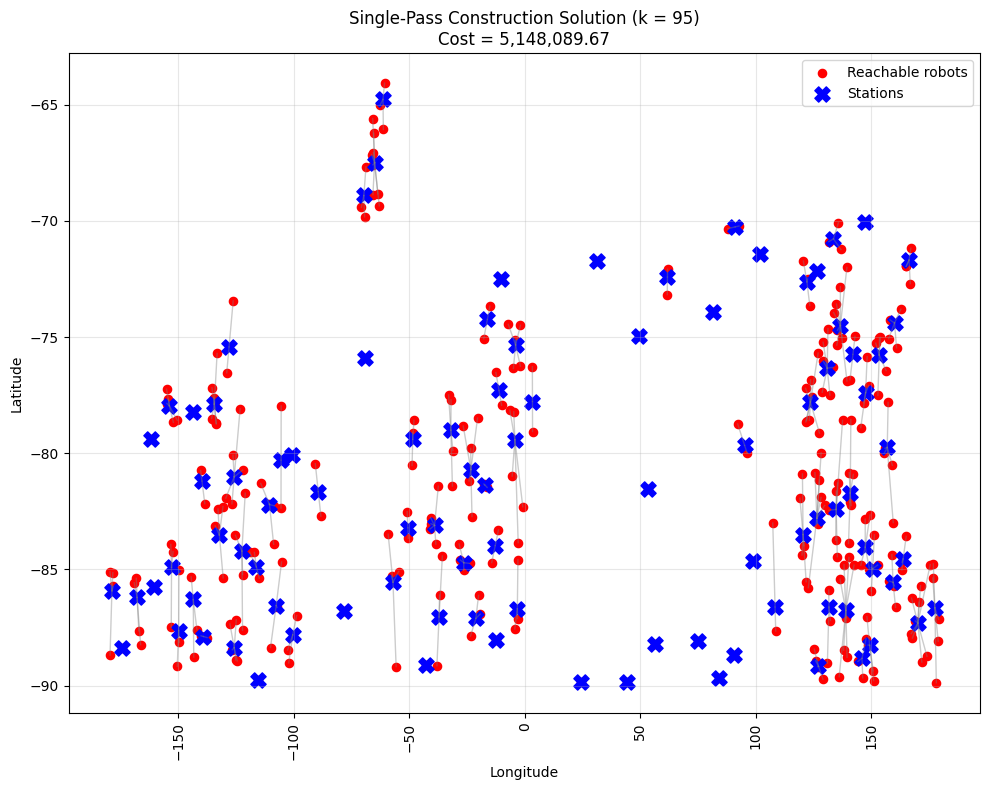

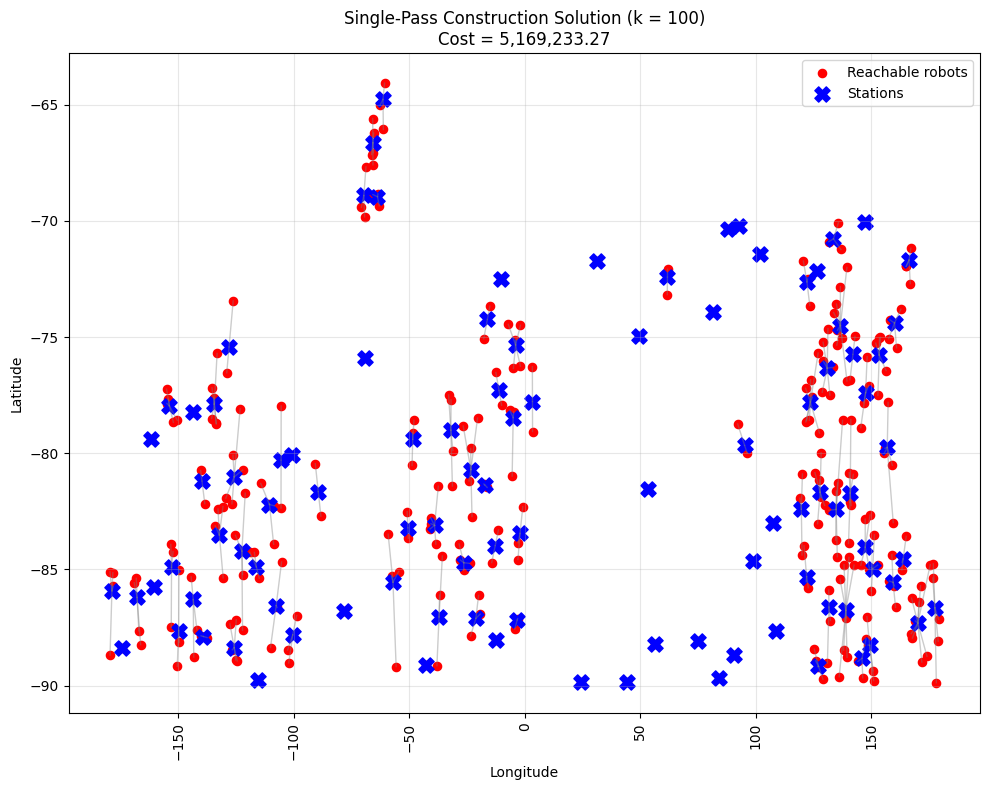

In [45]:
for k in summary_by_k["k"]:
    result = results_by_k[k]
    stations_df = result["final_stations"]
    assignments_df = result["final_assignments"]
    total_cost = result["final_total_cost"]

    fig, ax = plt.subplots(figsize=(10, 8))

    transport_robot_ids = set(
        assignments_df.loc[assignments_df["unreachable"] == 1, "robot_id"]
    )

    reachable_robots = robots_subset[~robots_subset["robot_id"].isin(transport_robot_ids)]
    transport_robots = robots_subset[robots_subset["robot_id"].isin(transport_robot_ids)]

    ax.scatter(reachable_robots["longitude"], reachable_robots["latitude"], c="red", s=35, label="Reachable robots")

    if not transport_robots.empty:
        ax.scatter(transport_robots["longitude"], transport_robots["latitude"], c="darkorange", s=50, label="Transport-needed robots")

    ax.scatter(stations_df["longitude"], stations_df["latitude"], c="blue", s=120, marker="X", label="Stations")

    for _, row in assignments_df.iterrows():
        robot = robots_subset[robots_subset["robot_id"] == row["robot_id"]].iloc[0]
        station = stations_df[stations_df["station_id"] == row["station_id"]].iloc[0]
        line_color = "darkorange" if row["unreachable"] == 1 else "gray"
        ax.plot(
            [robot["longitude"], station["longitude"]],
            [robot["latitude"], station["latitude"]],
            color=line_color,
            alpha=0.4,
            linewidth=1
        )

    ax.set_title(f"Single-Pass Construction Solution (k = {k})\nCost = {total_cost:,.2f}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
